<a href="https://colab.research.google.com/github/aaaraafaat/Data-Visualization-Storytelling/blob/main/Data_Wrangling_and_VIsualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv ('https://raw.githubusercontent.com/aaaraafaat/Data-Science/refs/heads/main/laptop_pricing_dataset_mod1.csv')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB
None


In [ ]:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [ ]:
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']],2)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


#Evaluate the dataset for missing data

In [ ]:
missing_data = df.isnull()
print(missing_data.head())
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

   Unnamed: 0  Manufacturer  Category  Screen    GPU     OS  CPU_core  \
0       False         False     False   False  False  False     False   
1       False         False     False   False  False  False     False   
2       False         False     False   False  False  False     False   
3       False         False     False   False  False  False     False   
4       False         False     False   False  False  False     False   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0           False          False   False           False      False  False  
1           False          False   False           False      False  False  
2           False          False   False           False      False  False  
3           False          False   False           False      False  False  
4           False          False   False           False      False  False  
Unnamed: 0
Unnamed: 0
False    238
Name: count, dtype: int64

Manufacturer
Manufacturer
False    23

#Replace with mean

In [ ]:
# replacing missing data with mean
avg_weight=df['Weight_kg'].astype('float').mean(axis=0)
df["Weight_kg"].replace(np.nan, avg_weight, inplace=True)

# astype() function converts the values to the desired data type
# axis=0 indicates that the mean value is to calculated across all column elements in a row.

/tmp/ipython-input-707358088.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weight_kg"].replace(np.nan, avg_weight, inplace=True)


In [ ]:
# replacing missing data with mode
common_screen_size = df['Screen_Size_cm'].value_counts().idxmax()
df["Screen_Size_cm"].replace(np.nan, common_screen_size, inplace=True)

/tmp/ipython-input-2852884260.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Screen_Size_cm"].replace(np.nan, common_screen_size, inplace=True)


#Fixing the data types
Both "Weight_kg" and "Screen_Size_cm" are seen to have the data type "Object", while both of them should be having a data type of "float". Write a code to fix the data type of these two columns.

In [ ]:
df[["Weight_kg","Screen_Size_cm"]] = df[["Weight_kg","Screen_Size_cm"]].astype("float")

#Data Standardization

In [ ]:
# Data standardization: convert weight from kg to pounds
df["Weight_kg"] = df["Weight_kg"]*2.205
df.rename(columns={'Weight_kg':'Weight_pounds'}, inplace=True)

# Data standardization: convert screen size from cm to inch
df["Screen_Size_cm"] = df["Screen_Size_cm"]/2.54
df.rename(columns={'Screen_Size_cm':'Screen_Size_inch'}, inplace=True)

#Data Normalization

In [ ]:
df['CPU_frequency'] = df['CPU_frequency']/df['CPU_frequency'].max()

#Binning

In [ ]:
bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
group_names = ['Low', 'Medium', 'High']
df['Price-binned'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True )

#Indicator variables

In [ ]:
#Indicator Variable: Screen
dummy_variable_1 = pd.get_dummies(df["Screen"])
dummy_variable_1.rename(columns={'IPS Panel':'Screen-IPS_panel', 'Full HD':'Screen-Full_HD'}, inplace=True)
df = pd.concat([df, dummy_variable_1], axis=1)

# drop original column "Screen" from "df"
df.drop("Screen", axis = 1, inplace=True)

In [ ]:
df.head(5)

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,False,True
1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,True,False
2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,True,False
3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,False,True
4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,True,False


In [ ]:
import seaborn as sns

#

<Axes: xlabel='Screen_Size_inch', ylabel='Price'>

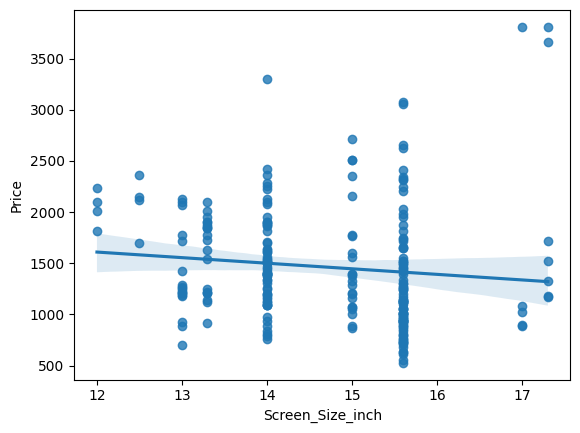

In [ ]:
sns.regplot(x = 'Screen_Size_inch',y = 'Price',data= df)

Treee Map

Treemaps are a form of data visualization that displays hierarchical data using nested rectangles. Each branch of the hierarchy is given a rectangle, which is then tiled with smaller rectangles representing sub-branches. Treemaps are particularly useful for visualizing large datasets where the hierarchical structure is crucial, offering an intuitive and space-efficient way to display data.

Business Analytics: Visualizing the composition of sales by product categories and subcategories.
Finance: Displaying the performance of stock portfolios, sectors, and industries.
IT and Network Management: Representing file systems or network usage, showing the distribution of files and folders.
Bioinformatics: Displaying hierarchical biological data, such as taxonomies or genomic structures.
Website Analytics: Showing the structure of website traffic, with rectangles representing web pages and their size indicating the volume of visits.

In [ ]:
pip install plotly pandas

In [ ]:
import pandas as pd
import plotly.express as px

In [ ]:
fig = px.treemap(df,
                 path=['Screen_Size_inch', 'Price'],  # Define hierarchical structure
                 values='GPU',  # Size of each rectangle
                 title='Treemap Example')  # Title of the treemap

In [ ]:
fig.show()

In [ ]:
fig = px.treemap(
    df,
    path=['Manufacturer', 'Screen_Size_inch'],
    values='Price',
    title='Laptop Market Share by Manufacturer and Screen Size'
)
fig.show()


In [ ]:

# 2. Advanced Treemap (with Color)
# This adds a color scale based on Price.
# Darker/Redder might mean more expensive, depending on the colorscale.
fig2 = px.treemap(
    df,
    path=['Manufacturer', 'RAM_GB'],
    values='Price',
    color='Price',
    color_continuous_scale='RdBu',
    title='Laptop Pricing Hierarchy: Brand -> RAM'
)
fig2.show()

Pivot Charts : Pivot charts are a powerful tool used for data visualization and analysis. They allow users to dynamically summarize and explore large datasets, revealing insights and trends that might not be immediately obvious. Pivot charts are widely used in business intelligence, finance, marketing, and various other fields where data analysis is crucial.

In [ ]:
pivot_table = df.pivot_table(values='Price', index='CPU_core', columns=['Manufacturer','RAM_GB'], aggfunc='sum')


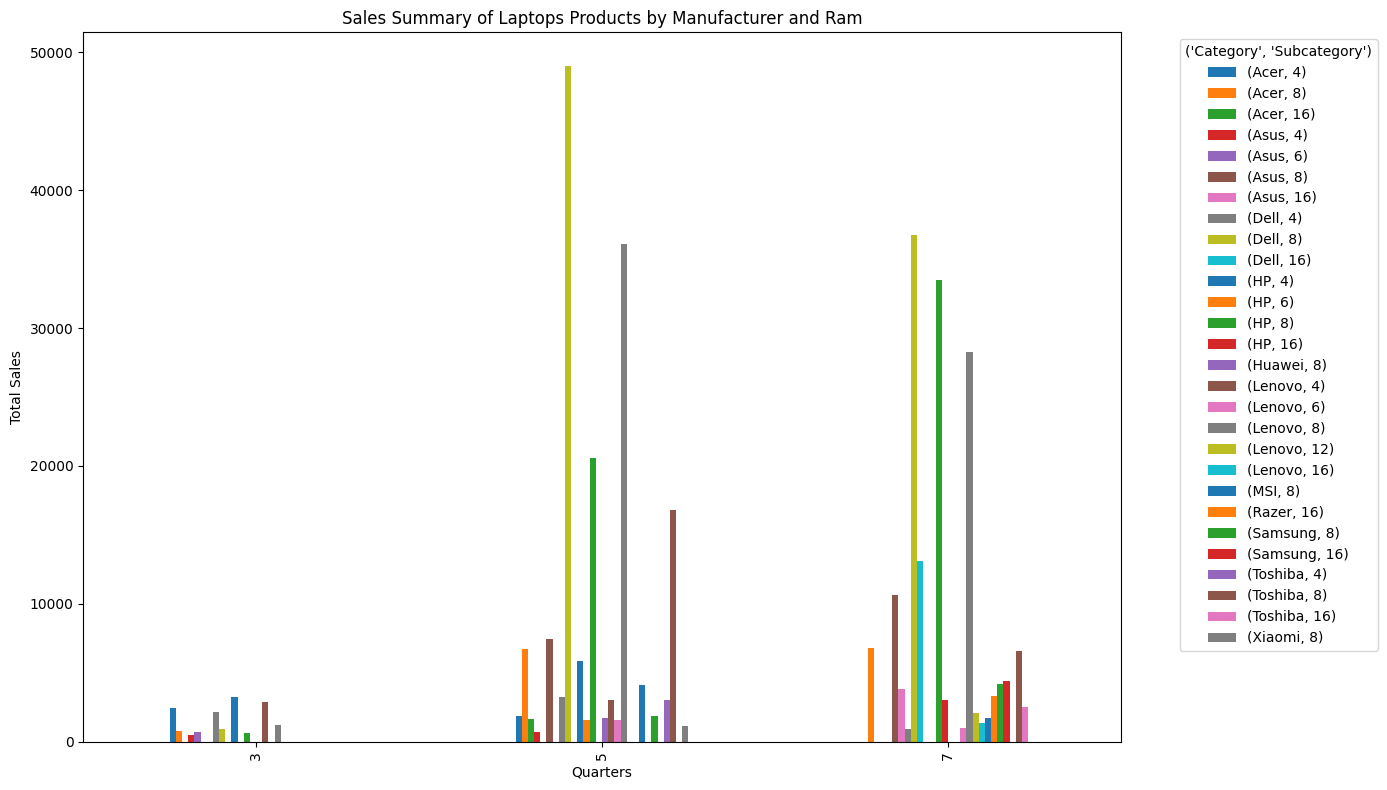

In [ ]:
#Plotting a pivot chart
pivot_table.plot(kind='bar', figsize=(14, 8))
plt.title('Sales Summary of Laptops Products by Manufacturer and Ram')
plt.xlabel('Quarters')
plt.ylabel('Total Sales')
plt.grid(False)
plt.legend(title=('Category', 'Subcategory'), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()